In [43]:
!pip install -r requirements.txt

In [99]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from helpers import get_iso3

In [100]:
# We can see from the first research question that the biggest polluters are:
#1. China - CHN
#2. US - USA
#3. Russia - RUS
#4. Japan - JPN
#5. Germany - DEU
#6. India - IND
#7. UK - GBR
#8. Saudi Arabia - SAU
#9. Iran - IRN
#10. France FRA

goliaths_iso3 = ['CHN', 'USA', 'RUS', 'JPN', 'DEU', 'IND', 'GBR', 'SAU', 'IRN', 'FRA']

In [101]:
file_path = "data/CRDF-DP-all years-2012-2023.xlsx"
xl = pd.ExcelFile(file_path)
print(xl.sheet_names)

['NOTES', 'All']


In [102]:
df_provider = pd.read_excel(file_path, sheet_name=1)
df_provider.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 164491 entries, 0 to 164490
Data columns (total 38 columns):
 #   Column                                                                                         Non-Null Count   Dtype  
---  ------                                                                                         --------------   -----  
 0   Year                                                                                           164491 non-null  int64  
 1   Provider Type                                                                                  164491 non-null  object 
 2   Provider                                                                                       164491 non-null  object 
 3   Provider (detailed)                                                                            164491 non-null  object 
 4   Provider Code                                                                                  164491 non-null  int64  
 5   Agency Co

In [103]:
# Only columns relevant to the analysis are retained
cols_to_keep = [
    'Year',
    'Provider',
    'Climate-related development finance - Commitment - 2023 USD thousand',
    'Recipient',
    'Financial Instrument'
]

df_provider = df_provider[cols_to_keep]
df_provider.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 164491 entries, 0 to 164490
Data columns (total 5 columns):
 #   Column                                                                Non-Null Count   Dtype  
---  ------                                                                --------------   -----  
 0   Year                                                                  164491 non-null  int64  
 1   Provider                                                              164491 non-null  object 
 2   Climate-related development finance - Commitment - 2023 USD thousand  164491 non-null  float64
 3   Recipient                                                             164491 non-null  object 
 4   Financial Instrument                                                  164147 non-null  object 
dtypes: float64(1), int64(1), object(3)
memory usage: 6.3+ MB


In [104]:
# Checking for null values
df_provider.isna().sum()

Year                                                                      0
Provider                                                                  0
Climate-related development finance - Commitment - 2023 USD thousand      0
Recipient                                                                 0
Financial Instrument                                                    344
dtype: int64

In [105]:
# Since there are 344 unknown values for categories, a new category "Uncategorized" will be created to accommodate them 
df_provider['Financial Instrument'] = df_provider['Financial Instrument'].fillna('Uncategorized')

In [106]:
# Adding a 'provider_iso3' column to represent the ISO3 code of the provider
df_provider['provider_iso3'] = df_provider['Provider'].apply(get_iso3)

In [107]:
# Check if any provider is missing a corresponding ISO3 code
missing = df_provider[df_provider['provider_iso3'].isna()]['Provider'].unique()
missing

array(['EU Institutions (excl. EIB)', 'Korea', 'Russia', 'Chinese Taipei'],
      dtype=object)

In [108]:
manual_map = {
    'Russia': 'RUS',
    'Korea': 'KOR',               # South Korea
    'Chinese Taipei': 'TWN',
    'EU Institutions (excl. EIB)': 'EU'
}
df_provider['provider_iso3'] = df_provider.apply(
    lambda row: manual_map[row['Provider']] if pd.isna(row['provider_iso3']) and row['Provider'] in manual_map else row['provider_iso3'],
    axis=1
)

In [109]:
df_provider[df_provider['provider_iso3'].isna()]['Provider'].unique()

array([], dtype=object)

In [110]:
# Adding an additional column indicating whether the provider is a Goliath or not
df_provider['is_goliath'] = df_provider['provider_iso3'].isin(goliaths_iso3)

In [111]:
df_provider['Financial Instrument'].value_counts(dropna=False)

Financial Instrument
Grant                                                  160822
Debt instrument                                          2847
Equity and shares in collective investment vehicles       430
Uncategorized                                             344
Debt relief                                                29
Mezzanine finance instrument                               19
Name: count, dtype: int64

In [112]:
# Different types of assistance are observed:
# 1. Grant – non-repayable funds; the recipient country does not return the money, representing true aid.
# 2. Debt instrument – a loan that must be repaid by the recipient country; considered aid but increases the country's debt.
# 3. Equity and shares in collective investment vehicles – investment in capital; the donor becomes a co-owner, more of an investment than aid.
# 4. Debt relief – partial cancellation of existing debt.
# 5. Mezzanine finance instrument – a hybrid form of financing between debt and equity; provided as a loan, but riskier than a standard loan. 
#    If the project cannot repay, the donor may receive partial ownership.

In [113]:
df_provider['is_goliath'].value_counts()

is_goliath
False    92637
True     71854
Name: count, dtype: int64

In [114]:
total_by_goliath = (
    df_provider
    .groupby('is_goliath')['Climate-related development finance - Commitment - 2023 USD thousand']
    .sum()
    .reset_index()
)
total_by_goliath

,is_goliath,Climate-related development finance - Commitment - 2023 USD thousand
0,False,1.775346e+08
1,True,3.662684e+08


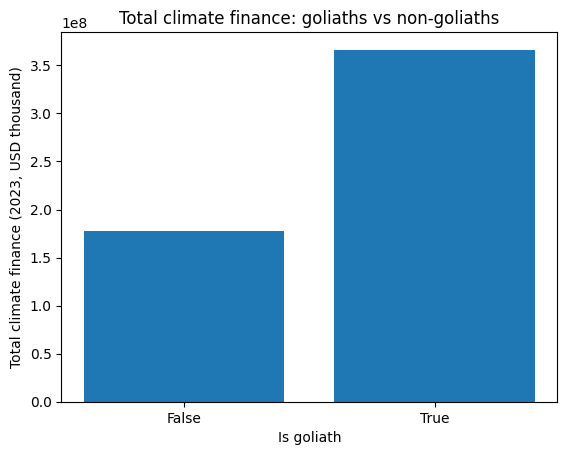

In [115]:
plt.figure()
plt.bar(
    total_by_goliath['is_goliath'].astype(str),
    total_by_goliath['Climate-related development finance - Commitment - 2023 USD thousand']
)
plt.xlabel('Is goliath')
plt.ylabel('Total climate finance (2023, USD thousand)')
plt.title('Total climate finance: goliaths vs non-goliaths')
plt.show()


In [116]:
# Observed in constant 2023 USD, countries classified as 'Goliaths' allocate a higher absolute amount of climate-related development 
# finance (366.3 million USD) compared to other countries (177.5 million USD). However, the key issue is not only the total amount, 
# but also the method and structure of financing, which is analyzed in more detail below.

In [117]:
instrument_split = (
    df_provider
    .groupby(['is_goliath', 'Financial Instrument'])[
        'Climate-related development finance - Commitment - 2023 USD thousand'
    ]
    .sum()
    .reset_index()
)
instrument_split

,is_goliath,Financial Instrument,Climate-related development finance - Commitment - 2023 USD thousand
0,False,Debt instrument,1.314976e+07
1,False,Debt relief,6.956700e+04
2,False,Equity and shares in collective investment veh...,1.347368e+06
3,False,Grant,1.576875e+08
4,False,Mezzanine finance instrument,1.463912e+05
5,False,Uncategorized,5.134071e+06
6,True,Debt instrument,1.953244e+08
7,True,Debt relief,3.229892e+04
8,True,Equity and shares in collective investment veh...,6.616239e+06
9,True,Grant,1.490439e+08


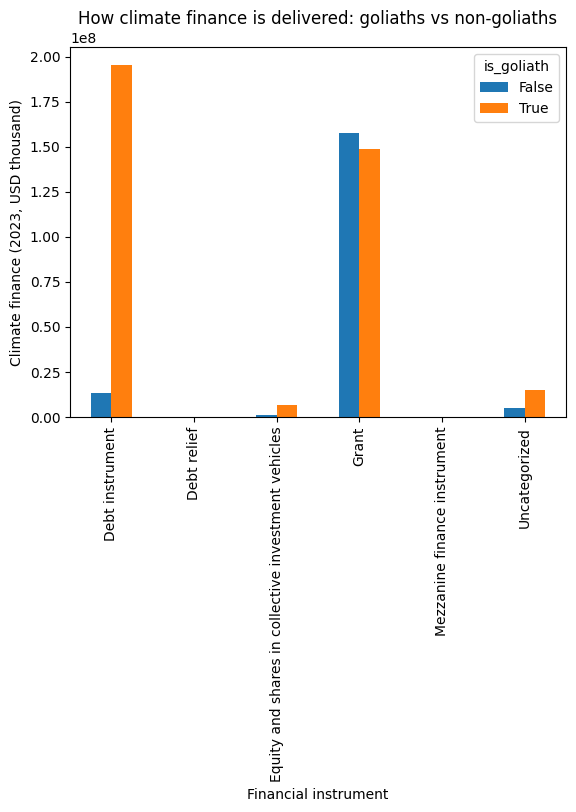

In [118]:
pivot_instr = instrument_split.pivot(
    index='Financial Instrument',
    columns='is_goliath',
    values='Climate-related development finance - Commitment - 2023 USD thousand'
).fillna(0)
pivot_instr.plot(kind='bar')
plt.xlabel('Financial instrument')
plt.ylabel('Climate finance (2023, USD thousand)')
plt.title('How climate finance is delivered: goliaths vs non-goliaths')
plt.show()

In [119]:
# The financing structure shows that 'Goliaths' allocate the majority of funds through debt instruments (195.3 million USD), 
# whereas grants dominate among other countries (157.7 million USD). Although Goliaths provide a higher total amount, 
# their assistance is largely loan-based, while other donors have a higher share of non-repayable support.

In [120]:
df_provider['Year'].unique()

array([2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022,
       2023])

In [121]:
# The number of projects has increased over the years, likely reflecting a growing demand for funding.
df_provider['Year'].value_counts().sort_index()

Year
2012     7654
2013     7879
2014     7833
2015     7912
2016     8538
2017    10101
2018    10452
2019    12785
2020    17133
2021    20223
2022    25131
2023    28850
Name: count, dtype: int64

In [122]:
goliath_total = (
    df_provider[df_provider['is_goliath'] == True]
    .groupby('Provider')[
        'Climate-related development finance - Commitment - 2023 USD thousand'
    ]
    .sum()
    .sort_values()
)

goliath_total

Provider
Saudi Arabia      3.901324e+05
Russia            3.957349e+05
United Kingdom    3.108903e+07
United States     4.234013e+07
France            7.021751e+07
Japan             1.056477e+08
Germany           1.161882e+08
Name: Climate-related development finance - Commitment - 2023 USD thousand, dtype: float64

In [123]:
# Although Saudi Arabia ranks eighth among major polluters, it appears among the donors, but its absolute contribution is small
# (390.1 thousand USD).  
# The largest amounts come from Germany, Japan, and France, with the United States also providing a significant contribution.  
# This indicates that the ranking of donations does not follow the list of top emitters, especially since China and India are not
# represented in the dataset.

In [124]:
goliath_by_instrument = (
    df_provider[df_provider['is_goliath'] == True]
    .groupby(['Provider', 'Financial Instrument'])[
        'Climate-related development finance - Commitment - 2023 USD thousand'
    ]
    .sum()
    .reset_index()
)

pivot_goliath = goliath_by_instrument.pivot(
    index='Provider',
    columns='Financial Instrument',
    values='Climate-related development finance - Commitment - 2023 USD thousand'
).fillna(0)

pivot_goliath

Financial Instrument,Debt instrument,Debt relief,Equity and shares in collective investment vehicles,Grant,Mezzanine finance instrument,Uncategorized
Provider,,,,,,
France,5.127299e+07,0.000000,8.620078e+05,1.058467e+07,0.000000,7.497845e+06
Germany,5.511241e+07,0.000000,2.055785e+06,5.624228e+07,0.000000,2.777691e+06
Japan,8.717731e+07,0.000000,1.770673e+06,1.669968e+07,0.000000,0.000000e+00
Russia,0.000000e+00,0.000000,0.000000e+00,3.957349e+05,0.000000,0.000000e+00
Saudi Arabia,2.876430e+04,0.000000,0.000000e+00,3.613681e+05,0.000000,0.000000e+00
United Kingdom,5.839245e+05,25298.427573,1.571274e+06,2.864176e+07,35766.314481,2.310053e+05
United States,1.149027e+06,7000.490722,3.565000e+05,3.611838e+07,0.000000,4.709224e+06


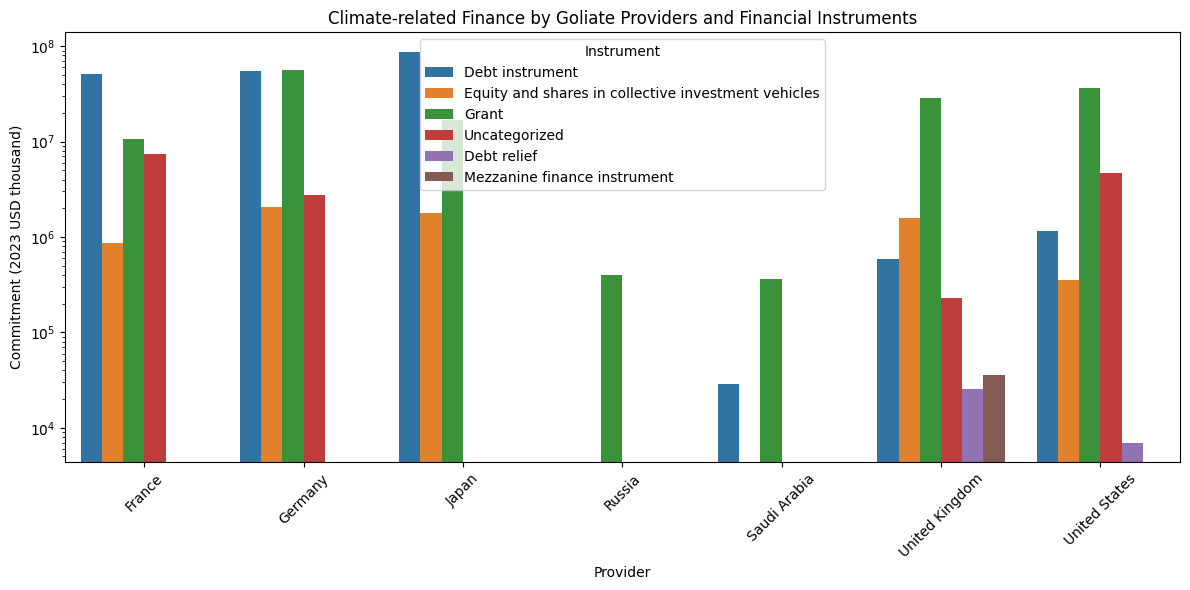

In [125]:
plt.figure(figsize=(12,6))
sns.barplot(
    data=goliath_by_instrument, 
    x='Provider', 
    y='Climate-related development finance - Commitment - 2023 USD thousand', 
    hue='Financial Instrument'
)
plt.yscale('log')
plt.xticks(rotation=45)
plt.ylabel('Commitment (2023 USD thousand)')
plt.title('Climate-related Finance by Goliate Providers and Financial Instruments')
plt.legend(title='Instrument')
plt.tight_layout()
plt.show()


In [126]:
# Calculating the share of each type of assistance for each Goliath

total_per_provider = goliath_by_instrument.groupby('Provider')[
    'Climate-related development finance - Commitment - 2023 USD thousand'
].sum().reset_index().rename(columns={
    'Climate-related development finance - Commitment - 2023 USD thousand': 'Total'
})

df_percent = goliath_by_instrument.merge(total_per_provider, on='Provider')

df_percent['Percent'] = (
    df_percent['Climate-related development finance - Commitment - 2023 USD thousand'] 
    / df_percent['Total'] * 100
)

df_pivot = df_percent.pivot(index='Provider', columns='Financial Instrument', values='Percent').fillna(0)
df_pivot_percent = df_pivot.style.format("{:.1f} %")
df_pivot_percent


Financial Instrument,Debt instrument,Debt relief,Equity and shares in collective investment vehicles,Grant,Mezzanine finance instrument,Uncategorized
Provider,,,,,,
France,73.0 %,0.0 %,1.2 %,15.1 %,0.0 %,10.7 %
Germany,47.4 %,0.0 %,1.8 %,48.4 %,0.0 %,2.4 %
Japan,82.5 %,0.0 %,1.7 %,15.8 %,0.0 %,0.0 %
Russia,0.0 %,0.0 %,0.0 %,100.0 %,0.0 %,0.0 %
Saudi Arabia,7.4 %,0.0 %,0.0 %,92.6 %,0.0 %,0.0 %
United Kingdom,1.9 %,0.1 %,5.1 %,92.1 %,0.1 %,0.7 %
United States,2.7 %,0.0 %,0.8 %,85.3 %,0.0 %,11.1 %


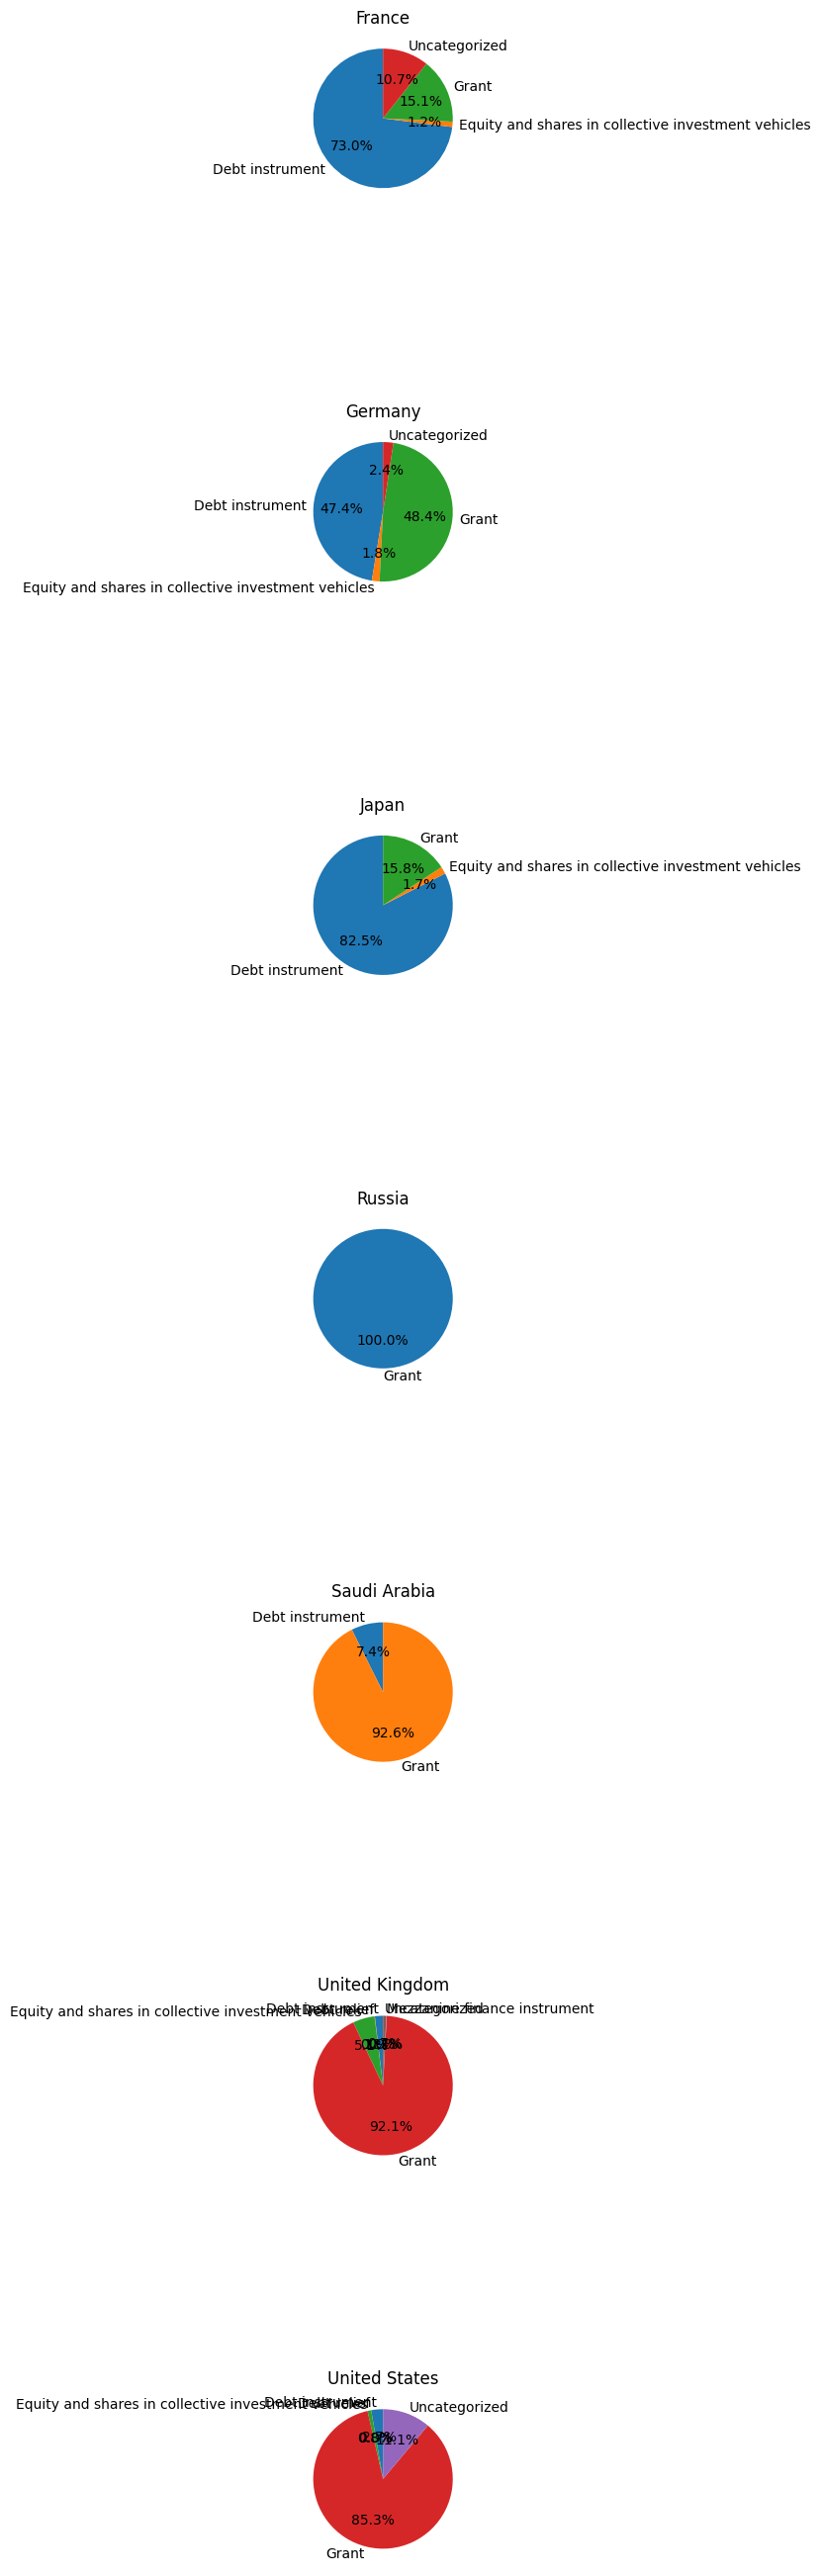

In [130]:
providers = df_percent['Provider'].unique()
n = len(providers)

fig, axes = plt.subplots(n, 1, figsize=(6, 4*n))

for i, provider in enumerate(providers):
    data = df_percent[df_percent['Provider'] == provider]
    axes[i].pie(
        data['Percent'], 
        labels=data['Financial Instrument'], 
        autopct='%1.1f%%',
        startangle=90
    )
    axes[i].set_title(provider)

plt.tight_layout()
plt.show()

In [131]:
# CONCLUSION:
# Three distinct models of Goliath behavior are observed. The first model is loan-based, dominated by Japan (#4 polluter) and France (#10). 
# Japan allocates 82.5% of its assistance through debt instruments, while France allocates 73%. In this model, recipient countries face not 
# only climate-related challenges but also the burden of debt repayment.  
# The second model emphasizes a high proportion of non-repayable support. The United Kingdom (#7) and the United States (#2) dominate 
# with over 92% and 85% of assistance provided as grants, respectively. Germany (#5) exhibits a balanced model (almost 50-50 between 
# debt and grants), which is notable given the high absolute amounts provided.  
# The third model represents anomalies, where Russia (#3) and Saudi Arabia (#8) provide almost exclusively grants (100% and 92.6%, 
# respectively), but their absolute contributions are the smallest.